# 🌈 Audio AI v2 - Part 2: Time-to-Frequency Transformations (FFT, STFT & Mel)
## Slicing Sound into 2D Matrices: From 1D Waveforms to Grayscale Images

Welcome to Part 2! Here we answer the single biggest question every software engineer asks when entering Audio AI:
> *"What does Time Domain vs. Frequency Domain actually mean in code?"*

In this notebook, we learn:
1. **FFT (Fast Fourier Transform)**: Reverse-engineering a mixed audio wave into component frequency notes (like decompiling a binary executable).
2. **Pitch ($F_0$) & Harmonics**: Finding the fundamental vocal cord frequency via `argmax` in the human pitch range.
3. **STFT (Short-Time Fourier Transform)**: Using the LeetCode Sliding Window algorithm to generate a 2D Spectrogram Matrix.
4. **The Heisenberg Trade-off**: CPU profiler sampling granularity (Window size trade-off).
5. **The Mel Scale**: Psychoacoustic non-linear frequency bucketing via matrix multiplication ($\mathbf{W}_{\text{mel}} \times \mathbf{S}$).

> 💡 **Developer Rule**: Above every code block, **Understanding Notes for Developers** explain the software engineering intuition, array shapes, and classic interview questions.


### 🧠 Understanding Notes: Environment Setup for Spectral Analysis
#### Connecting 1D Signal Processing to Linear Algebra

- **What libraries are we loading?**
  - `scipy.fft`: Highly optimized C implementation of the Fast Fourier Transform (`rfft` for real-valued audio).
  - `librosa`: Computes Short-Time Fourier Transforms and pre-computes triangular Mel filterbank matrices.
  - `matplotlib.pyplot`: Visualizing 1D spectra histograms and 2D spectrogram heatmaps.
- **Why do we care as software engineers?**
  Once audio is converted from a 1D waveform into a 2D spectrogram, **audio becomes a Computer Vision problem!**


In [1]:
# Setup and libraries
!pip install -q soundfile librosa matplotlib numpy scipy
import numpy as np
import soundfile as sf
import scipy.fft
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
print("Ready for spectral analysis!")

Ready for spectral analysis!


### 🧠 Understanding Notes: Fast Fourier Transform (FFT) & Fundamental Pitch ($F_0$)
#### Decompiling a Mixed Audio Thread into Notes

- **The Developer Mental Model for FFT:**
  - **Time-Domain (Waveform)**: Shows **WHEN** the microphone moved, but not **WHAT NOTES** were playing. It's like looking at raw memory bytes.
  - **Frequency-Domain (FFT)**: A decompiler or reverse pattern-matcher. It scans the 1D array and outputs a histogram of how strong each frequency pattern is:
    - *Bin @ 120 Hz: Strength 0.85 (Fundamental Pitch $F_0$)*
    - *Bin @ 240 Hz: Strength 0.45 (2nd Harmonic)*
    - *Bin @ 360 Hz: Strength 0.20 (3rd Harmonic)*
- **Harmonics: Why Human Voice Isn't a Pure Beep:**
  - A single frequency is an artificial electronic sine beep.
  - Human vocal cords snap shut abruptly, producing a rich train of integer multiples: $F_0, 2F_0, 3F_0, 4F_0, \dots$
- **Detecting Gender Pitch via `argmax`:**
  - **Male Vocal Cords**: Longer and heavier $\to$ flap slowly $\to$ **$F_0 \approx 85 - 180\text{ Hz}$**.
  - **Female Vocal Cords**: Shorter and lighter $\to$ flap faster $\to$ **$F_0 \approx 165 - 255\text{ Hz}$**.
  - In code, finding pitch is as simple as finding the maximum magnitude bin between $80\text{ Hz}$ and $300\text{ Hz}$!


Female Vowel Peak F0: 210.0 Hz (Expected: 165 - 255 Hz)
Male Vowel Peak F0:   110.0 Hz (Expected: 85 - 180 Hz)


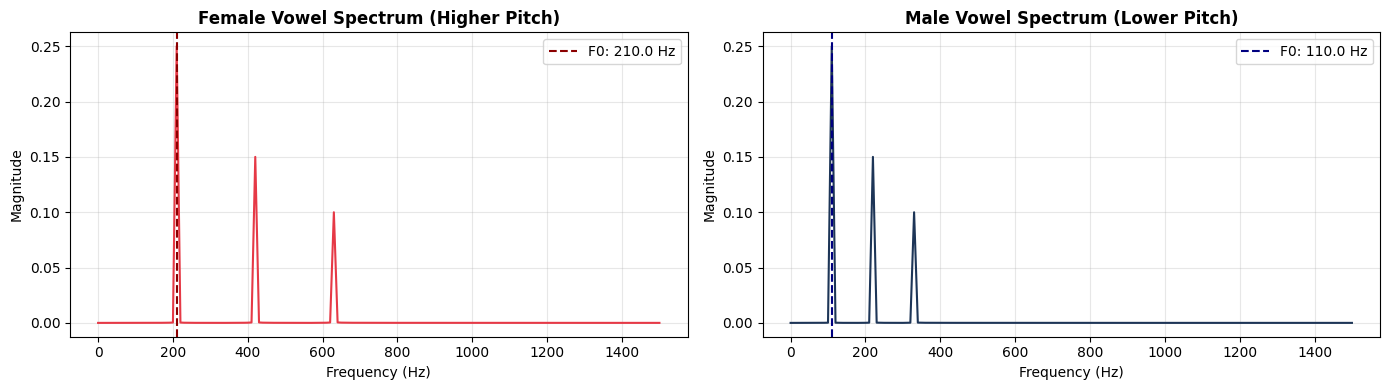

In [4]:
# Helper: Load audio and compute FFT
def compute_fft(signal: np.ndarray, sr: int):
    N = len(signal)
    fft_vals = scipy.fft.rfft(signal)
    freqs = scipy.fft.rfftfreq(N, d=1.0 / sr)
    magnitudes = np.abs(fft_vals) / N
    # Detect dominant pitch peak in speech range (60-500 Hz)
    mask = (freqs >= 60) & (freqs <= 500)
    peak_idx = np.argmax(magnitudes[mask]) if np.any(mask) else 0
    f0_proxy = float(freqs[mask][peak_idx]) if np.any(mask) else 0.0
    return freqs, magnitudes, f0_proxy

# Load sample female and male audio
p_f = "../data/raw/2277_2277-149896-0026.wav"
p_m = "../data/raw/777_777-126732-0074.wav"
if not os.path.exists(p_f):
    sr = 16000
    t = np.linspace(0, 1.0, sr)
    sig_f = 0.5*np.sin(2*np.pi*210*t) + 0.3*np.sin(2*np.pi*420*t) + 0.2*np.sin(2*np.pi*630*t)
    sig_m = 0.5*np.sin(2*np.pi*110*t) + 0.3*np.sin(2*np.pi*220*t) + 0.2*np.sin(2*np.pi*330*t)
    sr_f = sr_m = sr
else:
    sig_f, sr_f = sf.read(p_f, dtype="float32")
    sig_m, sr_m = sf.read(p_m, dtype="float32")
    if sig_f.ndim > 1: sig_f = np.mean(sig_f, axis=1)
    if sig_m.ndim > 1: sig_m = np.mean(sig_m, axis=1)

# Extract a stable 100ms vowel section
chunk_f = sig_f[int(0.0*sr_f):int(0.1*sr_f)]
chunk_m = sig_m[int(0.0*sr_m):int(0.1*sr_m)]

freqs_f, mags_f, f0_f = compute_fft(chunk_f, sr_f)
freqs_m, mags_m, f0_m = compute_fft(chunk_m, sr_m)

print(f"Female Vowel Peak F0: {f0_f:.1f} Hz (Expected: 165 - 255 Hz)")
print(f"Male Vowel Peak F0:   {f0_m:.1f} Hz (Expected: 85 - 180 Hz)")

# Plot FFT Spectra
plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(freqs_f[freqs_f <= 1500], mags_f[freqs_f <= 1500], color="#E63946")
plt.axvline(f0_f, color="darkred", linestyle="--", label=f"F0: {f0_f:.1f} Hz")
plt.title("Female Vowel Spectrum (Higher Pitch)", fontweight="bold")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude"); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(freqs_m[freqs_m <= 1500], mags_m[freqs_m <= 1500], color="#1D3557")
plt.axvline(f0_m, color="navy", linestyle="--", label=f"F0: {f0_m:.1f} Hz")
plt.title("Male Vowel Spectrum (Lower Pitch)", fontweight="bold")
plt.xlabel("Frequency (Hz)"); plt.ylabel("Magnitude"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 🧠 Understanding Notes: Short-Time Fourier Transform (STFT)
#### Slicing Audio into a 2D Heatmap (The LeetCode Sliding Window Algorithm)

- **Why a Single FFT Fails:**
  If you run FFT on a 5-second sentence: *"HELLO WORLD"*, it tells you what frequencies occurred, but wipes out all timestamps! Did "HELLO" happen at second 1 or second 4? You cannot tell!
- **How STFT Works (Sliding Window Algorithm):**
  1. Slice a small window of the audio array (e.g., $1024$ samples $\approx 64\text{ ms}$).
  2. Multiply by a **Hann window** (bell curve tapering edges to zero to prevent boundary clicks / spectral leakage).
  3. Run FFT on this slice.
  4. Hop forward by $256$ samples ($\approx 16\text{ ms}$).
  5. Stack the output columns into a 2D matrix of shape `(Frequency_Bins, Time_Frames)`.
- **The Window Size Trade-Off (Profiler Sampling Granularity):**
  - **Narrow-Band ($N_{\text{fft}} = 2048$, $128\text{ ms}$)**: Pinpoint frequency accuracy ($7.81\text{ Hz}$/bin) $\to$ razor-sharp horizontal harmonic lines, but blurred time stamps.
  - **Wide-Band ($N_{\text{fft}} = 256$, $16\text{ ms}$)**: Pinpoint time accuracy ($16\text{ ms}$/bin) $\to$ razor-sharp vertical pulse lines, but blurry pitch harmonics.
  - $N_{\text{fft}} = 1024$ ($64\text{ ms}$) is the proven sweet spot for Speech AI.


Narrow-band STFT Shape: (1025, 63) (High freq resolution: 1025 bins)
Wide-band STFT Shape:   (129, 63) (High time resolution: 129 bins)


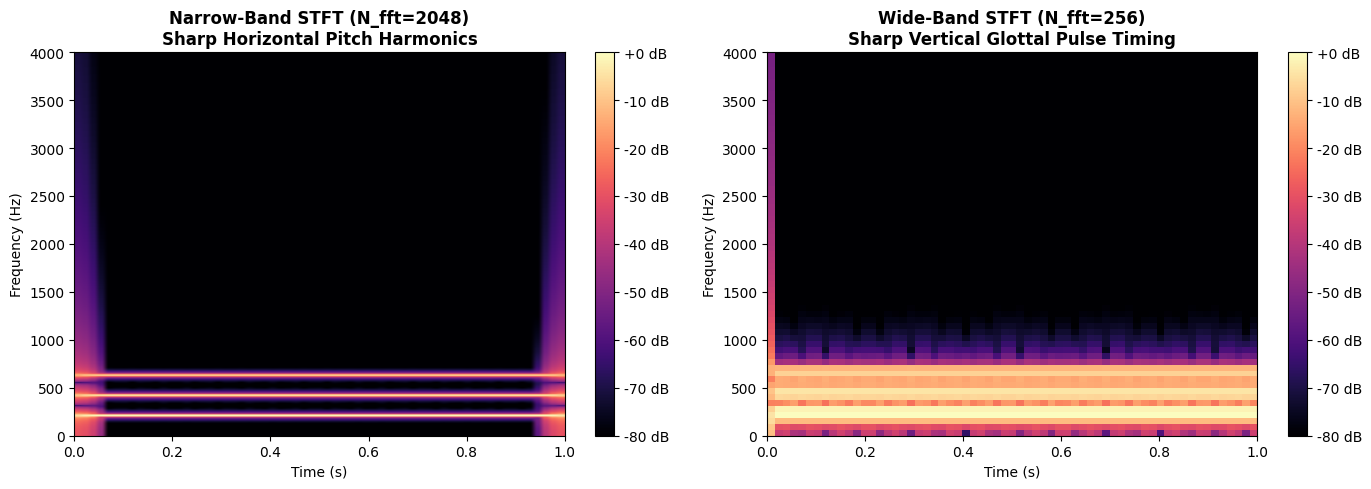

In [6]:
# STFT Comparison
hop_length = 256
stft_narrow = librosa.power_to_db(np.abs(librosa.stft(sig_f, n_fft=2048, hop_length=hop_length))**2, ref=np.max)
stft_wide   = librosa.power_to_db(np.abs(librosa.stft(sig_f, n_fft=256, hop_length=hop_length, win_length=256))**2, ref=np.max)

print("Narrow-band STFT Shape:", stft_narrow.shape, "(High freq resolution: 1025 bins)")
print("Wide-band STFT Shape:  ", stft_wide.shape, "(High time resolution: 129 bins)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
im1 = ax1.imshow(stft_narrow, aspect="auto", origin="lower", cmap="magma", extent=[0, len(sig_f)/sr_f, 0, sr_f/2])
ax1.set_ylim([0, 4000])
ax1.set_title("Narrow-Band STFT (N_fft=2048)\nSharp Horizontal Pitch Harmonics", fontweight="bold")
ax1.set_xlabel("Time (s)"); ax1.set_ylabel("Frequency (Hz)")
plt.colorbar(im1, ax=ax1, format="%+2.0f dB")

im2 = ax2.imshow(stft_wide, aspect="auto", origin="lower", cmap="magma", extent=[0, len(sig_f)/sr_f, 0, sr_f/2])
ax2.set_ylim([0, 4000])
ax2.set_title("Wide-Band STFT (N_fft=256)\nSharp Vertical Glottal Pulse Timing", fontweight="bold")
ax2.set_xlabel("Time (s)"); ax2.set_ylabel("Frequency (Hz)")
plt.colorbar(im2, ax=ax2, format="%+2.0f dB")
plt.tight_layout(); plt.show()

### 🧠 Understanding Notes: The Mel Spectrogram
#### Non-Linear Perceptual Bucketing (Matrix Multiplication)

- **The Problem with Linear STFT Spectrograms:**
  - A linear spectrogram has $513$ rows from $0\text{ Hz}$ to $8,000\text{ Hz}$.
  - Rows $0$ to $120$ ($0 - 2,000\text{ Hz}$) contain $100\%$ of speech formants and vocal cord pitch.
  - Rows $121$ to $512$ ($2,000 - 8,000\text{ Hz}$) are mostly empty air hisses.
  - **$75\%$ of your matrix memory and neural net parameters are wasted on high frequencies humans cannot even distinguish!**
- **What is the Mel Filterbank in Code?**
  - It is **literally just a matrix multiplication**:
    $$\mathbf{S}_{\text{mel}} = \mathbf{W}_{\text{mel}} \times \mathbf{S}_{\text{linear}}$$
  - $\mathbf{W}_{\text{mel}}$ is a pre-computed triangular weighting matrix of shape `(80, 513)`.
  - It compresses $513$ linear rows into **$80$ Mel rows**, packed densely where speech vowels live.
  - Taking `librosa.power_to_db` applies a log transform, producing the **Log-Mel Spectrogram** — the gold standard 2D image fed into Audio CNNs and Whisper!
- **What to look for in the plot:**
  - Female voices have strong energy concentrations reaching up into higher Mel bands ($30 - 60$).
  - Male voices have energy concentrated heavily in the lowest Mel bands ($0 - 30$).


Mel Filter Bank Matrix Shape: (80, 513) (80 triangular filters across 513 FFT bins)
Female Log-Mel Spectrogram Shape: (80, 63) (80 Mel channels x 63 Time frames)
Male Log-Mel Spectrogram Shape:   (80, 63) (80 Mel channels x 63 Time frames)


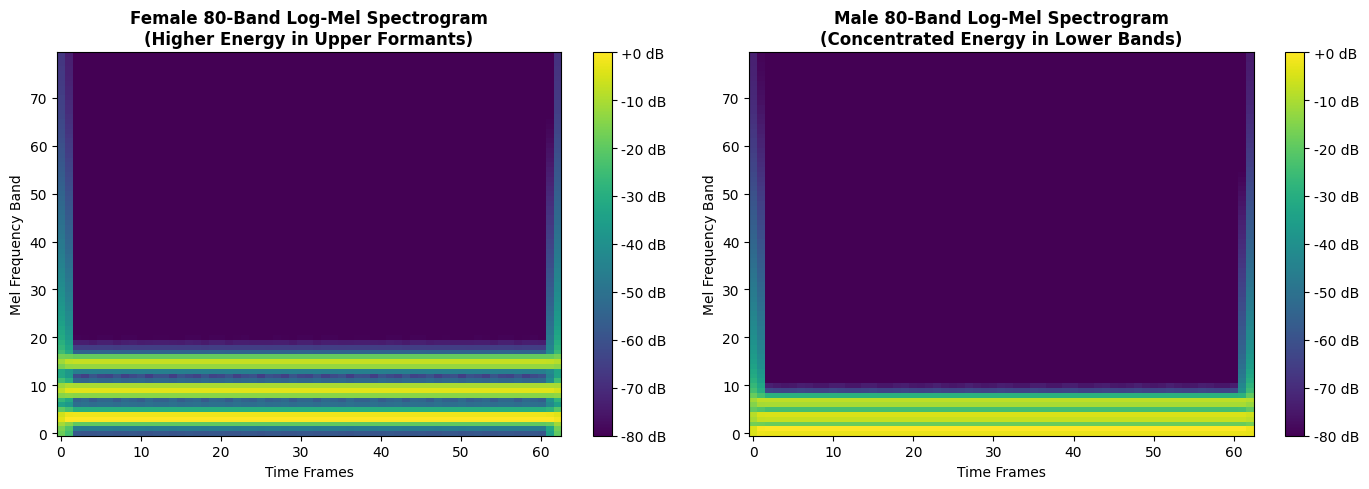

In [7]:
# Generate and Visualize Mel Filter Banks and Log-Mel Spectrogram
n_mels = 80
mel_filters = librosa.filters.mel(sr=sr_f, n_fft=1024, n_mels=n_mels, fmin=50, fmax=8000)
print(f"Mel Filter Bank Matrix Shape: {mel_filters.shape} ({n_mels} triangular filters across 513 FFT bins)")

# Compute Log-Mel Spectrograms for Female and Male
mel_f = librosa.power_to_db(librosa.feature.melspectrogram(y=sig_f, sr=sr_f, n_fft=1024, hop_length=256, n_mels=80, fmin=50, fmax=8000), ref=np.max)
mel_m = librosa.power_to_db(librosa.feature.melspectrogram(y=sig_m, sr=sr_m, n_fft=1024, hop_length=256, n_mels=80, fmin=50, fmax=8000), ref=np.max)

print(f"Female Log-Mel Spectrogram Shape: {mel_f.shape} (80 Mel channels x {mel_f.shape[1]} Time frames)")
print(f"Male Log-Mel Spectrogram Shape:   {mel_m.shape} (80 Mel channels x {mel_m.shape[1]} Time frames)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
im1 = ax1.imshow(mel_f, aspect="auto", origin="lower", cmap="viridis")
ax1.set_title("Female 80-Band Log-Mel Spectrogram\n(Higher Energy in Upper Formants)", fontweight="bold")
ax1.set_xlabel("Time Frames"); ax1.set_ylabel("Mel Frequency Band")
plt.colorbar(im1, ax=ax1, format="%+2.0f dB")

im2 = ax2.imshow(mel_m, aspect="auto", origin="lower", cmap="viridis")
ax2.set_title("Male 80-Band Log-Mel Spectrogram\n(Concentrated Energy in Lower Bands)", fontweight="bold")
ax2.set_xlabel("Time Frames"); ax2.set_ylabel("Mel Frequency Band")
plt.colorbar(im2, ax=ax2, format="%+2.0f dB")
plt.tight_layout(); plt.show()